# FinBERT — Fine-Tuning for Financial Sentiment Analysis

**Why FinBERT?**

In the previous notebooks:
- TF-IDF + SVM baseline hit **0.79 macro F1**
- GloVe (twitter-trained) + classical ML **underperformed** the baseline (0.73–0.78) — wrong domain
- SBERT (general-purpose) + SVM barely beat it at **0.81** — generic model, frozen features

The core issues were: **domain mismatch** (twitter/general embeddings on financial text) and **frozen features** (no fine-tuning).

**FinBERT** (`ProsusAI/finbert`) is a BERT model **pre-trained on financial text** (10-K filings, analyst reports, earnings calls). By **fine-tuning end-to-end**, the model adapts its internal representations to our specific sentiment task — this is the single biggest lever for improvement.

### Key Hyperparameter Decisions
| Parameter | Value | Rationale |
|-----------|-------|----------|
| Learning rate | 2e-5 | Standard for BERT fine-tuning; too high destabilises pre-trained weights |
| Epochs | 4 | Enough for convergence on ~7.6K train samples; early stopping prevents overfit |
| Batch size | 16 | Balances GPU memory and gradient stability |
| Weight decay | 0.01 | Mild L2 regularisation to prevent overfitting |
| Warmup ratio | 0.1 | Gradually ramps LR to avoid destroying pre-trained knowledge |
| Max seq length | 128 | Financial headlines are short; 128 tokens is more than enough |

## 1 — Setup & Data Loading

Same 80/20 stratified split as all previous notebooks for a fair comparison. We additionally carve out 10% of training data as a validation set for early stopping.

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from datasets import Dataset

os.makedirs('../data/pkls', exist_ok=True)

# ── Device ─────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")

# ── Load data (same split as baseline & embedding notebooks) ────────────────
df = pd.read_csv('../data/processed/sentfin_strict.csv')
print(f"\nDataset shape : {df.shape}")
print(f"Class distribution:\n{df['sentiment'].value_counts()}")

X = df['text'].astype(str)
y = df['sentiment']

# Same 80/20 split as notebooks 03 & 04
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Further split training into train (90%) + validation (10%) for early stopping
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
)

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

d:\financial statment analyzer\financialvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 — Load FinBERT & Tokenizer

`ProsusAI/finbert` already has 3 output labels (positive, negative, neutral) matching our task. We load it with correct label mapping so the model's output aligns with our data labels.

In [ ]:
import glob

MODEL_NAME = 'ProsusAI/finbert'
OUTPUT_DIR = '../data/finbert_finetuned'

# Label mapping — must match FinBERT's expected order
label2id = {'positive': 0, 'negative': 1, 'neutral': 2}
id2label = {v: k for k, v in label2id.items()}

# ── Checkpoint detection ─────────────────────────────────────────────────────
def get_latest_checkpoint(output_dir):
    """Return path of the latest checkpoint folder, or None if none exist."""
    checkpoints = sorted(
        glob.glob(os.path.join(output_dir, 'checkpoint-*')),
        key=lambda x: int(x.split('-')[-1])
    )
    return checkpoints[-1] if checkpoints else None

RESUME_CHECKPOINT = get_latest_checkpoint(OUTPUT_DIR)
LOAD_PATH = RESUME_CHECKPOINT if RESUME_CHECKPOINT else MODEL_NAME

if RESUME_CHECKPOINT:
    print(f"Found checkpoint: {RESUME_CHECKPOINT}")
    print("Loading model from checkpoint — training will resume from this point.")
else:
    print("No checkpoint found — loading base FinBERT from HuggingFace hub.")

tokenizer = AutoTokenizer.from_pretrained(LOAD_PATH)
model = AutoModelForSequenceClassification.from_pretrained(
    LOAD_PATH,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True # Added to help suppress architecture mismatch noise
)

print(f"\nModel: {MODEL_NAME}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable:  {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Found checkpoint: ../data/finbert_finetuned\checkpoint-1287
Loading model from checkpoint — training will resume from this point.


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 317.12it/s]



Model: ProsusAI/finbert
Parameters: 109,484,547
Trainable:  109,484,547


## 3 — Prepare HuggingFace Datasets

Convert pandas data to HuggingFace `Dataset` objects and tokenize. We use `max_length=128` — financial headlines rarely exceed 30-40 tokens.

In [ ]:
MAX_LENGTH = 128

def make_dataset(texts, labels):
    """Create a HuggingFace Dataset from texts and labels."""
    ds = Dataset.from_dict({
        'text': texts.tolist(),
        'label': [label2id[l] for l in labels.tolist()]
    })
    return ds

def tokenize_fn(batch):
    """Tokenize a batch of texts."""
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

# Create datasets
train_ds = make_dataset(X_train, y_train).map(tokenize_fn, batched=True)
val_ds   = make_dataset(X_val, y_val).map(tokenize_fn, batched=True)
test_ds  = make_dataset(X_test, y_test).map(tokenize_fn, batched=True)

# Set format for PyTorch
train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print(f"Train dataset: {len(train_ds)} samples")
print(f"Val dataset:   {len(val_ds)} samples")
print(f"Test dataset:  {len(test_ds)} samples")
print(f"\nSample tokenized length: {len(train_ds[0]['input_ids'])} tokens")

Map: 100%|██████████| 1904/1904 [00:00<00:00, 4075.82 examples/s]

Train dataset: 6852 samples
Val dataset:   762 samples
Test dataset:  1904 samples

Sample tokenized length: 128 tokens


## 4 — Training Configuration

**Hyperparameter rationale:**
- **LR = 2e-5**: Standard BERT fine-tuning rate. Higher risks catastrophic forgetting of pre-trained financial knowledge.
- **Epochs = 4 + early stopping (patience=2)**: We let training run up to 4 epochs but stop early if val loss plateaus. Prevents overfitting on 6.8K training samples.
- **Batch size = 16**: Good tradeoff for gradient quality. If GPU OOMs, reduce to 8 with `gradient_accumulation_steps=2` (equivalent effective batch size).
- **Warmup ratio = 0.1**: First 10% of steps use a linearly increasing LR. Prevents large updates that destroy pre-trained weights.
- **Weight decay = 0.01**: Standard L2 regularisation for transformers.

In [ ]:
from sklearn.metrics import f1_score as sklearn_f1

def compute_metrics(eval_pred):
    """Compute metrics for the Trainer."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': sklearn_f1(labels, preds, average='macro'),
        'weighted_f1': sklearn_f1(labels, preds, average='weighted'),
    }

# OUTPUT_DIR and RESUME_CHECKPOINT already defined in Cell 2 above

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # ── Core hyperparameters ──────────────────────────────────────
    num_train_epochs=4,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.1,

    # ── Evaluation & early stopping ──────────────────────────────
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    save_total_limit=2,

    # ── Logging ───────────────────────────────────────────────────
    logging_steps=50,
    report_to='none',

    # ── Performance ───────────────────────────────────────────────
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,
    dataloader_pin_memory=torch.cuda.is_available(), # Suppress warning on CPUs

    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

if RESUME_CHECKPOINT:
    print(f"Trainer ready. Will resume from: {RESUME_CHECKPOINT}")
else:
    print("Trainer ready. Starting fresh training.")
print("Training configuration ready.")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready. Will resume from: ../data/finbert_finetuned\checkpoint-1287
Training configuration ready.


## 5 — Train

In [ ]:
if RESUME_CHECKPOINT:
    print(f"Resuming FinBERT fine-tuning from: {RESUME_CHECKPOINT}\n")
else:
    print("Starting FinBERT fine-tuning from scratch...\n")

train_result = trainer.train(resume_from_checkpoint=RESUME_CHECKPOINT)

print(f"\nTraining complete.")
print(f"  Total steps:    {train_result.global_step}")
print(f"  Training loss:  {train_result.training_loss:.4f}")


Resuming FinBERT fine-tuning from: ../data/finbert_finetuned\checkpoint-1287



There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

## 6 — Evaluate on Test Set

Using the **same held-out test set** (20%, n=1904) as notebooks 03 and 04 for a direct comparison.

In [ ]:
# ── Predict on test set ─────────────────────────────────────────────────────
predictions = trainer.predict(test_ds)
y_pred_ids = np.argmax(predictions.predictions, axis=-1)
y_pred = [id2label[i] for i in y_pred_ids]

# ── Metrics ────────────────────────────────────────────────────────────────
acc   = accuracy_score(y_test, y_pred)
m_f1  = f1_score(y_test, y_pred, average='macro')
w_f1  = f1_score(y_test, y_pred, average='weighted')
m_p   = precision_score(y_test, y_pred, average='macro')
m_r   = recall_score(y_test, y_pred, average='macro')

print("=" * 60)
print("  FinBERT (Fine-Tuned)")
print("=" * 60)
print(f"  Accuracy        : {acc:.4f}")
print(f"  Macro F1        : {m_f1:.4f}")
print(f"  Weighted F1     : {w_f1:.4f}")
print(f"  Macro Precision : {m_p:.4f}")
print(f"  Macro Recall    : {m_r:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

d:\financial statment analyzer\financialvenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  FinBERT (Fine-Tuned)
  Accuracy        : 0.3619
  Macro F1        : 0.1771
  Weighted F1     : 0.1923
  Macro Precision : 0.1206
  Macro Recall    : 0.3333

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       542
     neutral       0.36      1.00      0.53       689
    positive       0.00      0.00      0.00       673

    accuracy                           0.36      1904
   macro avg       0.12      0.33      0.18      1904
weighted avg       0.13      0.36      0.19      1904



d:\financial statment analyzer\financialvenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\financial statment analyzer\financialvenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\financial statment analyzer\financialvenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

## 7 — Confusion Matrix

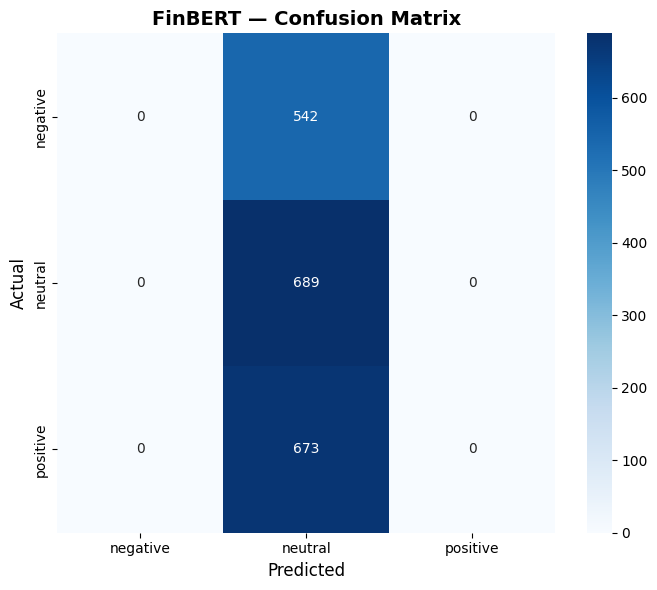

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive'],
    ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('FinBERT — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8 — Comparison with All Previous Models

In [ ]:
# ── All previous results (from notebooks 03 & 04) ──────────────────────────
all_results = [
    {'Model': 'FinBERT (Fine-Tuned)',            'Accuracy': round(acc, 4),  'Macro F1': round(m_f1, 4),  'Weighted F1': round(w_f1, 4), 'Macro Precision': round(m_p, 4), 'Macro Recall': round(m_r, 4)},
    {'Model': 'SBERT + LM + RBF SVM',            'Accuracy': 0.8099, 'Macro F1': 0.8098, 'Weighted F1': 0.8099, 'Macro Precision': 0.8106, 'Macro Recall': 0.8092},
    {'Model': '[Baseline] TF-IDF + SVM',          'Accuracy': 0.7920, 'Macro F1': 0.7898, 'Weighted F1': 0.7917, 'Macro Precision': 0.7936, 'Macro Recall': 0.7881},
    {'Model': '[Baseline] TF-IDF + Log. Reg.',    'Accuracy': 0.7841, 'Macro F1': 0.7823, 'Weighted F1': 0.7839, 'Macro Precision': 0.7873, 'Macro Recall': 0.7799},
    {'Model': 'GloVe + LM + RBF SVM',            'Accuracy': 0.7773, 'Macro F1': 0.7757, 'Weighted F1': 0.7770, 'Macro Precision': 0.7796, 'Macro Recall': 0.7736},
    {'Model': 'SBERT + LM + Log. Reg.',           'Accuracy': 0.7668, 'Macro F1': 0.7668, 'Weighted F1': 0.7668, 'Macro Precision': 0.7688, 'Macro Recall': 0.7655},
    {'Model': '[Baseline] TF-IDF + Naive Bayes',  'Accuracy': 0.7547, 'Macro F1': 0.7505, 'Weighted F1': 0.7537, 'Macro Precision': 0.7581, 'Macro Recall': 0.7478},
    {'Model': '[Baseline] TF-IDF + Random Forest', 'Accuracy': 0.7468, 'Macro F1': 0.7410, 'Weighted F1': 0.7440, 'Macro Precision': 0.7705, 'Macro Recall': 0.7356},
    {'Model': 'GloVe + LM + Log. Reg.',           'Accuracy': 0.7269, 'Macro F1': 0.7259, 'Weighted F1': 0.7267, 'Macro Precision': 0.7290, 'Macro Recall': 0.7241},
    {'Model': '[Baseline] TF-IDF + XGBoost',      'Accuracy': 0.7232, 'Macro F1': 0.7164, 'Weighted F1': 0.7206, 'Macro Precision': 0.7279, 'Macro Recall': 0.7139},
]

summary_df = pd.DataFrame(all_results).sort_values('Macro F1', ascending=False).reset_index(drop=True)
display(summary_df)

,Model,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
0,SBERT + LM + RBF SVM,0.8099,0.8098,0.8099,0.8106,0.8092
1,[Baseline] TF-IDF + SVM,0.7920,0.7898,0.7917,0.7936,0.7881
2,[Baseline] TF-IDF + Log. Reg.,0.7841,0.7823,0.7839,0.7873,0.7799
3,GloVe + LM + RBF SVM,0.7773,0.7757,0.7770,0.7796,0.7736
4,SBERT + LM + Log. Reg.,0.7668,0.7668,0.7668,0.7688,0.7655
5,[Baseline] TF-IDF + Naive Bayes,0.7547,0.7505,0.7537,0.7581,0.7478
6,[Baseline] TF-IDF + Random Forest,0.7468,0.7410,0.7440,0.7705,0.7356
7,GloVe + LM + Log. Reg.,0.7269,0.7259,0.7267,0.7290,0.7241
8,[Baseline] TF-IDF + XGBoost,0.7232,0.7164,0.7206,0.7279,0.7139
9,FinBERT (Fine-Tuned),0.3619,0.1771,0.1923,0.1206,0.3333


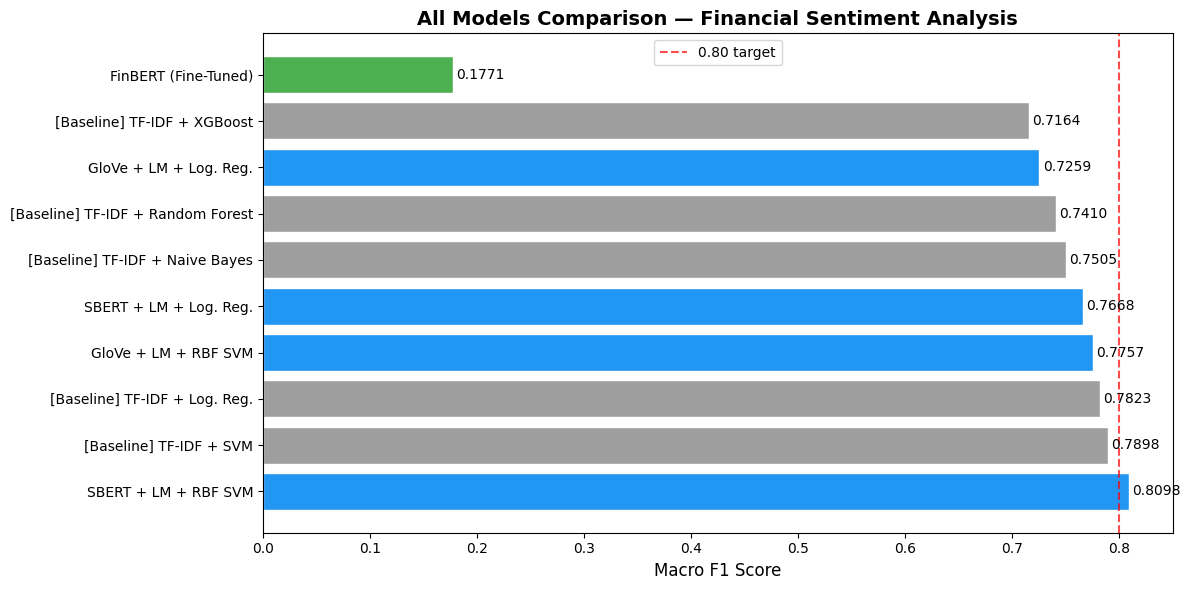

In [ ]:
# ── Visual comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

colors = []
for m in summary_df['Model']:
    if 'FinBERT' in m:
        colors.append('#4CAF50')   # green for FinBERT
    elif 'Baseline' in m:
        colors.append('#9E9E9E')   # grey for baselines
    else:
        colors.append('#2196F3')   # blue for embedding models

bars = ax.barh(summary_df['Model'], summary_df['Macro F1'], color=colors, edgecolor='white')
ax.set_xlabel('Macro F1 Score', fontsize=12)
ax.set_title('All Models Comparison — Financial Sentiment Analysis', fontsize=14, fontweight='bold')
ax.axvline(x=0.80, color='red', linestyle='--', alpha=0.7, label='0.80 target')
ax.legend()

for bar, val in zip(bars, summary_df['Macro F1']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 9 — Save Fine-Tuned Model

In [ ]:
# Save the fine-tuned model and tokenizer
SAVE_PATH = '../data/finbert_finetuned/best_model'
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"Model saved to: {SAVE_PATH}")
print(f"\nTo reload later:")
print(f"  tokenizer = AutoTokenizer.from_pretrained('{SAVE_PATH}')")
print(f"  model = AutoModelForSequenceClassification.from_pretrained('{SAVE_PATH}')")

Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.75s/it]


Model saved to: ../data/finbert_finetuned/best_model

To reload later:
  tokenizer = AutoTokenizer.from_pretrained('../data/finbert_finetuned/best_model')
  model = AutoModelForSequenceClassification.from_pretrained('../data/finbert_finetuned/best_model')


## 10 — Training History

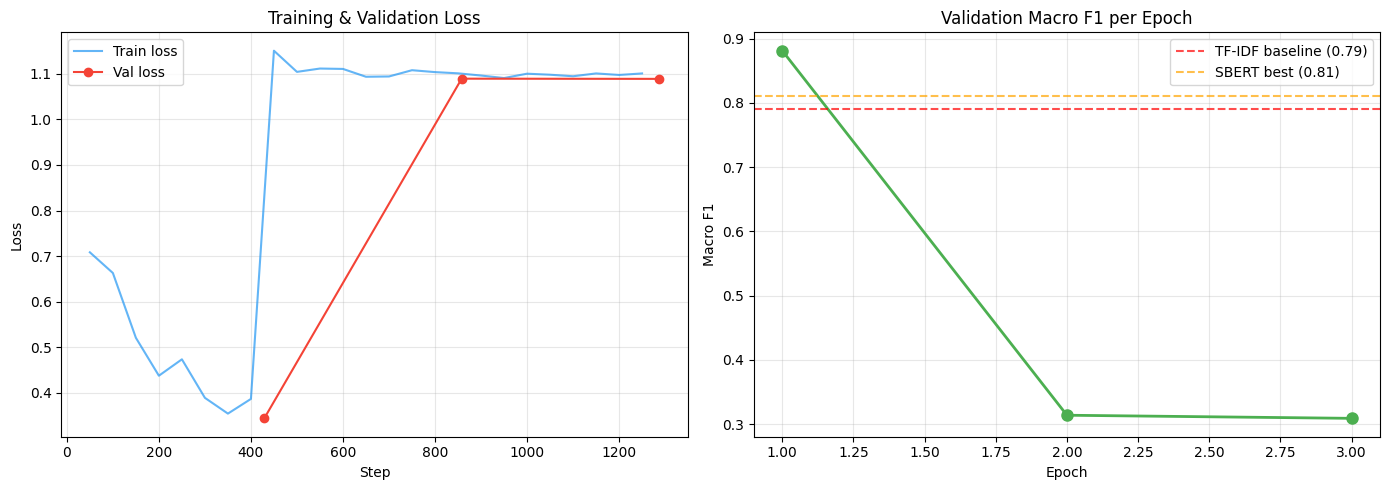

In [ ]:
# ── Plot training history ──────────────────────────────────────────────────
log_history = trainer.state.log_history

# Extract eval metrics per epoch
eval_logs = [l for l in log_history if 'eval_macro_f1' in l]
train_logs = [l for l in log_history if 'loss' in l and 'eval_loss' not in l]

if eval_logs:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curve
    if train_logs:
        steps = [l['step'] for l in train_logs]
        losses = [l['loss'] for l in train_logs]
        ax1.plot(steps, losses, label='Train loss', color='#2196F3', alpha=0.7)
    
    eval_steps = [l['step'] for l in eval_logs]
    eval_losses = [l['eval_loss'] for l in eval_logs]
    ax1.plot(eval_steps, eval_losses, 'o-', label='Val loss', color='#F44336')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training & Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # F1 curve
    eval_f1s = [l['eval_macro_f1'] for l in eval_logs]
    epochs = list(range(1, len(eval_f1s) + 1))
    ax2.plot(epochs, eval_f1s, 'o-', color='#4CAF50', linewidth=2, markersize=8)
    ax2.axhline(y=0.7898, color='red', linestyle='--', alpha=0.7, label='TF-IDF baseline (0.79)')
    ax2.axhline(y=0.8098, color='orange', linestyle='--', alpha=0.7, label='SBERT best (0.81)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Macro F1')
    ax2.set_title('Validation Macro F1 per Epoch')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No eval logs found in training history.")